# Sistema de Diagnóstico de Doenças com Machine Learning
Este projeto tem como objetivo prever a ocorrência de doenças da tireóide com base em dados médicos, utilizando técnicas de classificação supervisionada.

Datasets utilizados

[hipothyroid.data](https://github.com/Val-Faria/TechCahllenge_Tireoide/blob/main/dataset/hypothyroid.data)

[hipothyroid.names](https://github.com/Val-Faria/TechCahllenge_Tireoide/blob/main/dataset/hypothyroid.names)

Os dados foram obtidos de fontes públicas e utilizados em tarefas de classificação supervisionada para predição de doenças.


In [36]:
!git clone https://github.com/Val-Faria/TechCahllenge_Tireoide.git

Cloning into 'TechCahllenge_Tireoide'...
remote: Enumerating objects: 15, done.
remote: Counting objects: 100% (15/15), done.
remote: Compressing objects: 100% (12/12), done.
remote: Total 15 (delta 0), reused 3 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (15/15), 83.42 KiB | 4.91 MiB/s, done.


In [37]:
%cd TechCahllenge_Tireoide


/content/TechCahllenge_Tireoide/TechCahllenge_Tireoide


In [38]:
!git branch -a

* main
  remotes/origin/HEAD -> origin/main
  remotes/origin/feature_preprocessamento
  remotes/origin/main


In [39]:
!git checkout -b feature_preprocessamento

Switched to a new branch 'feature_preprocessamento'


In [40]:
!git branch

* feature_preprocessamento
  main


In [70]:
# Importação das bibliotecas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression


In [71]:
# Carregamento do dataset bruto
df = pd.read_csv('dataset/hypothyroid.data', header=None)
df.head()

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,hypothyroid,72,M,f,f,f,f,f,f,f,...,y,0.60,y,15,y,1.48,y,10,n,?
1,hypothyroid,15,F,t,f,f,f,f,f,f,...,y,1.70,y,19,y,1.13,y,17,n,?
2,hypothyroid,24,M,f,f,f,f,f,f,f,...,y,0.20,y,4,y,1,y,0,n,?
3,hypothyroid,24,F,f,f,f,f,f,f,f,...,y,0.40,y,6,y,1.04,y,6,n,?
4,hypothyroid,77,M,f,f,f,f,f,f,f,...,y,1.20,y,57,y,1.28,y,44,n,?


In [72]:
# Análise da dimensão dos dados, identificando quantidade de registros e
# variáveis
df.shape

(3163, 26)

In [73]:
# Análise inicial da estrutura dos dados, verificando tipos de variáveis e
# possíveis valores ausentes
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 26 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   0       3163 non-null   object
 1   1       3163 non-null   object
 2   2       3163 non-null   object
 3   3       3163 non-null   object
 4   4       3163 non-null   object
 5   5       3163 non-null   object
 6   6       3163 non-null   object
 7   7       3163 non-null   object
 8   8       3163 non-null   object
 9   9       3163 non-null   object
 10  10      3163 non-null   object
 11  11      3163 non-null   object
 12  12      3163 non-null   object
 13  13      3163 non-null   object
 14  14      3163 non-null   object
 15  15      3163 non-null   object
 16  16      3163 non-null   object
 17  17      3163 non-null   object
 18  18      3163 non-null   object
 19  19      3163 non-null   object
 20  20      3163 non-null   object
 21  21      3163 non-null   object
 22  22      3163 non-null   

O dataset possui 3.163 registros e 26 variáveis, sendo a maioria categórica (object) e apenas 7 numéricas (float64). Podemos observar a presença de valores ausentes em diversas colunas, especialmente na coluna 25, que apresenta grande quantidade de dados faltantes, indicando a necessidade de tratamento antes da modelagem. São 260 dados não nulos, restando 2903 nulos (3163-260 = 2903).

In [74]:
# Análise estatística inicial das variáveis numéricas para entender
# distribuição e possíveis outliers
df.describe(include='all')

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
count,3163,3163,3163,3163,3163,3163,3163,3163,3163,3163,...,3163,3163,3163,3163,3163,3163,3163,3163,3163,3163
unique,2,93,3,2,2,2,2,2,2,2,...,2,70,2,269,2,159,2,281,2,53
top,negative,?,F,f,f,f,f,f,f,f,...,y,?,y,?,y,?,y,?,n,?
freq,3012,446,2182,2702,3108,3121,3059,2922,2920,3100,...,2468,695,2914,249,2915,248,2916,247,2903,2903


In [75]:
# Análise de dados faltantes para identificar a presença de valores nulos em
# cada variável
df.isnull().sum()

,0
0,0
1,0
2,0
3,0
4,0
5,0
6,0
7,0
8,0
9,0


Podemos observar que existem dados nulos nas colunas "1", "2","15", "17", "19", "21", "23" e "25", que pode impactar o desempenho dos modelos e exige a imputação ou remoção, para garantir a qualidade dos dados.

In [76]:
# Carregamento do dataset bruto, definindo '?' como valor ausente (NaN)
df = pd.read_csv('dataset/hypothyroid.data', header=None, na_values='?')

In [77]:
# Análise de valores ausentes após conversão de '?' para NaN
df.isnull().sum()

,0
0,0
1,446
2,73
3,0
4,0
5,0
6,0
7,0
8,0
9,0


Após a conversão dos valores “?” para NaN, foi realizada a análise da distribuição de valores ausentes no dataset. Podemos observar que algumas variáveis apresentam ausência significativa de dados, como a coluna 25 (2903 valores nulos), além de outras colunas com quantidades relevantes de valores faltantes (ex: colunas 1, 15, 17, 19, 21 e 23). Esse cenário indica a necessidade de tratamento dos dados antes da etapa de modelagem, podendo envolver imputação, remoção de variáveis ou estratégias específicas para dados ausentes. A coluna 25 pode ser candidata a remoção, por apresentar uma grande quantidade de dados faltantes.

In [78]:
# Remoção de colunas com alta quantidade de valores ausentes
df = df.drop(columns=[25])

In [79]:
# Verificação da quantidade de colunas, após remoção
df.shape

(3163, 25)

In [80]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,hypothyroid,72.0,M,f,f,f,f,f,f,f,...,30.0,y,0.6,y,15.0,y,1.48,y,10.0,n
1,hypothyroid,15.0,F,t,f,f,f,f,f,f,...,145.0,y,1.7,y,19.0,y,1.13,y,17.0,n
2,hypothyroid,24.0,M,f,f,f,f,f,f,f,...,0.0,y,0.2,y,4.0,y,1.00,y,0.0,n
3,hypothyroid,24.0,F,f,f,f,f,f,f,f,...,430.0,y,0.4,y,6.0,y,1.04,y,6.0,n
4,hypothyroid,77.0,M,f,f,f,f,f,f,f,...,7.3,y,1.2,y,57.0,y,1.28,y,44.0,n


In [81]:
# Leitura do arquivo de descrição do dataset (.names) para compreender o
# significado e a ordem das variáveis

with open('dataset/hypothyroid.names', 'r') as f:
    print(f.read())

hypothyroid, negative.

age:				 continuous,?.
sex:				 M,F,?.
on_thyroxine:			 f,t.
query_on_thyroxine:		 f,t.
on_antithyroid_medication:	 f,t.
thyroid_surgery:		 f,t.
query_hypothyroid:		 f,t.
query_hyperthyroid:		 f,t.
pregnant:			 f,t.
sick:				 f,t.
tumor:				 f,t.
lithium:			 f,t.
goitre:				 f,t.
TSH_measured:			 f,t.
TSH:				 continuous,?.
T3_measured:			 f,t.
T3:				 continuous,?.
TT4_measured:			 f,t.
TT4:				 continuous,?.
T4U_measured:			 f,t.
T4U:				 continuous,?.
FTI_measured:			 f,t.
FTI:				 continuous,?.
TBG_measured:			 f,t.
TBG:				 continuous,?.




Verificamos que a coluna 0 corresponde à variável alvo (target), contendo as classes “hypothyroid” e “negative”, conforme indicado na documentação do dataset.

In [82]:
colunas = [
    'target',                  # 0
    'age',                     # 1
    'sex',                     # 2
    'on_thyroxine',            # 3
    'query_on_thyroxine',      # 4
    'on_antithyroid_medication', # 5
    'thyroid_surgery',         # 6
    'query_hypothyroid',       # 7
    'query_hyperthyroid',      # 8
    'pregnant',                # 9
    'sick',                    # 10
    'tumor',                   # 11
    'lithium',                 # 12
    'goitre',                  # 13
    'TSH_measured',            # 14
    'TSH',                     # 15
    'T3_measured',             # 16
    'T3',                      # 17
    'TT4_measured',            # 18
    'TT4',                     # 19
    'T4U_measured',            # 20
    'T4U',                     # 21
    'FTI_measured',            # 22
    'FTI',                     # 23
    'TBG'                      # 24
]

In [83]:
# Nomeação correta das colunas com base na documentação oficial do dataset
df.columns = colunas

In [84]:
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   target                     3163 non-null   object 
 1   age                        2717 non-null   float64
 2   sex                        3090 non-null   object 
 3   on_thyroxine               3163 non-null   object 
 4   query_on_thyroxine         3163 non-null   object 
 5   on_antithyroid_medication  3163 non-null   object 
 6   thyroid_surgery            3163 non-null   object 
 7   query_hypothyroid          3163 non-null   object 
 8   query_hyperthyroid         3163 non-null   object 
 9   pregnant                   3163 non-null   object 
 10  sick                       3163 non-null   object 
 11  tumor                      3163 non-null   object 
 12  lithium                    3163 non-null   object 
 13  goitre                     3163 non-null   objec

Embora a documentação do dataset mencione as variáveis TBG_measured e TBG, apenas a coluna TBG está presente nos dados analisados. A ausência de TBG_measured explica a quantidade total de 25 colunas no dataset.

In [85]:
# Análise da quantidade de valores ausentes por coluna
df.isnull().sum()

,0
target,0
age,446
sex,73
on_thyroxine,0
query_on_thyroxine,0
on_antithyroid_medication,0
thyroid_surgery,0
query_hypothyroid,0
query_hyperthyroid,0
pregnant,0


In [86]:
# Verificação final da estrutura e tipos de dados
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3163 entries, 0 to 3162
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   target                     3163 non-null   object 
 1   age                        2717 non-null   float64
 2   sex                        3090 non-null   object 
 3   on_thyroxine               3163 non-null   object 
 4   query_on_thyroxine         3163 non-null   object 
 5   on_antithyroid_medication  3163 non-null   object 
 6   thyroid_surgery            3163 non-null   object 
 7   query_hypothyroid          3163 non-null   object 
 8   query_hyperthyroid         3163 non-null   object 
 9   pregnant                   3163 non-null   object 
 10  sick                       3163 non-null   object 
 11  tumor                      3163 non-null   object 
 12  lithium                    3163 non-null   object 
 13  goitre                     3163 non-null   objec

In [87]:
# Revisão das estatísticas após tratamento
df.describe()

,age,TSH,T3,TT4,T4U,FTI
count,2717.000000,2695.000000,2468.000000,2914.000000,2915.000000,2916.000000
mean,51.154214,5.923180,1.939749,108.850000,0.978199,115.397771
std,19.294405,23.899467,0.996773,45.485419,0.226580,60.239572
min,1.000000,0.000000,0.000000,2.000000,0.000000,0.000000
25%,35.000000,0.000000,1.400000,83.000000,0.850000,91.000000
50%,54.000000,0.700000,1.800000,104.000000,0.960000,107.000000
75%,67.000000,2.300000,2.300000,128.000000,1.065000,129.000000
max,98.000000,530.000000,10.200000,450.000000,2.210000,881.000000


In [88]:
# Se não foi medido, valor = 0
df.loc[df['TSH_measured'] == 0, 'TSH'] = 0
df.loc[df['T3_measured'] == 0, 'T3'] = 0
df.loc[df['TT4_measured'] == 0, 'TT4'] = 0
df.loc[df['T4U_measured'] == 0, 'T4U'] = 0
df.loc[df['FTI_measured'] == 0, 'FTI'] = 0

In [89]:
# Preencher apenas onde deveria existir valor
for col in ['TSH', 'T3', 'TT4', 'T4U', 'FTI']:
    df[col] = df[col].fillna(df[col].mean())

As variáveis de exames apresentam valores ausentes associados à ausência de medição, indicada pelas colunas “_measured”. Para esses casos, valores não medidos foram preenchidos com zero, enquanto os demais foram imputados com a média.

In [90]:
df['age'] = df['age'].fillna(df['age'].mean())

In [91]:
df['sex'] = df['sex'].fillna(df['sex'].mode()[0])

In [92]:
# Análise da quantidade de valores ausentes por coluna, após tratamento
df.isnull().sum()

,0
target,0
age,0
sex,0
on_thyroxine,0
query_on_thyroxine,0
on_antithyroid_medication,0
thyroid_surgery,0
query_hypothyroid,0
query_hyperthyroid,0
pregnant,0


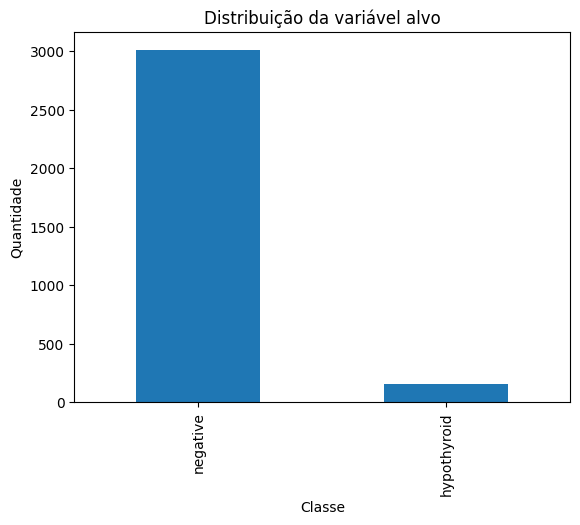

In [93]:
# Verificação do balanceamento das classes

df['target'].value_counts().plot(kind='bar')
plt.title('Distribuição da variável alvo')
plt.xlabel('Classe')
plt.ylabel('Quantidade')
plt.show()

Os dados apresentam um forte desbalanceamento entre as classes, com predominância significativa de casos “negative” em relação aos casos “hypothyroid”. Esse cenário pode levar o modelo a priorizar a classe majoritária, reduzindo sua capacidade de identificar corretamente os casos positivos.

Sendo assim, serão utilizadas métricas como recall e F1-score, que são mais adequadas para avaliar o desempenho em problemas com classes desbalanceadas, especialmente o recall da classe positiva, que é fundamental para reduzir falsos negativos.

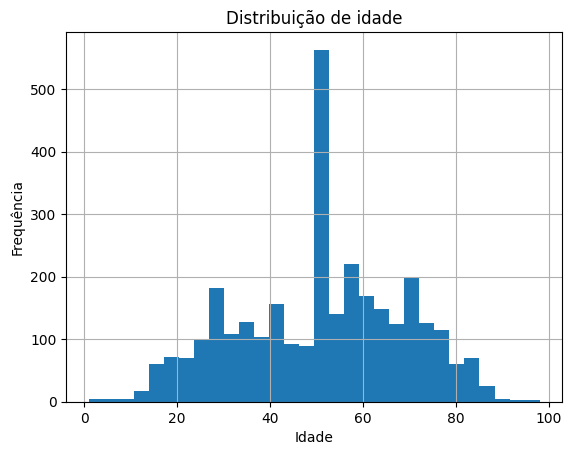

In [94]:
# Distribuição da idade dos pacientes

df['age'].hist(bins=30)
plt.title('Distribuição de idade')
plt.xlabel('Idade')
plt.ylabel('Frequência')
plt.show()

A maioria dos indivíduos está entre 40 e 70 anos, com maior concentração por volta dos 50 anos.
Há pessoas mais jovens e mais idosas, mas em menor quantidade.
Isso indica que o dataset é composto principalmente por adultos e pessoas mais velhas, o que pode influenciar os resultados da análise.

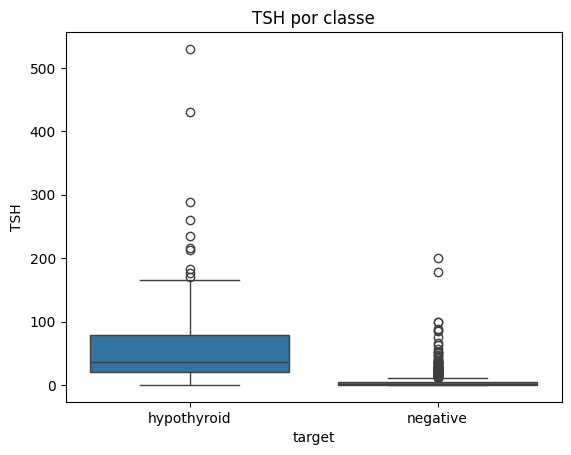

In [95]:
# Comparação de TSH entre as classes

sns.boxplot(x='target', y='TSH', data=df)
plt.title('TSH por classe')
plt.show()

Observa-se que os valores de TSH são, em geral, mais altos na classe “hypothyroid” em comparação com a classe “negative”.
A classe "negative" apresenta valores mais baixos e concentrados, enquanto a classe "hypothyroid" mostra maior variação e presença de valores elevados.
Também é possível notar alguns valores muito altos (outliers), principalmente na classe “hypothyroid”.
Isso indica que o TSH é uma variável importante para diferenciar as classes, sendo um forte indicativo da presença da condição.

In [96]:
# Estatísticas de TSH separadas por classe

df.groupby('target')['TSH'].describe()

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
hypothyroid,151.0,63.256445,74.196175,0.0,20.5,36.0,78.5,530.0
negative,3012.0,3.048903,7.980675,0.0,0.0,0.9,4.6,200.0


As estatísticas mostram que os valores de TSH são mais elevados na classe “hypothyroid”, confirmando o padrão observado no boxplot.
A variável TSH foi escolhida para análise detalhada por apresentar maior potencial de diferenciação entre as classes, sendo validada tanto visualmente quanto por meio de estatísticas descritivas.

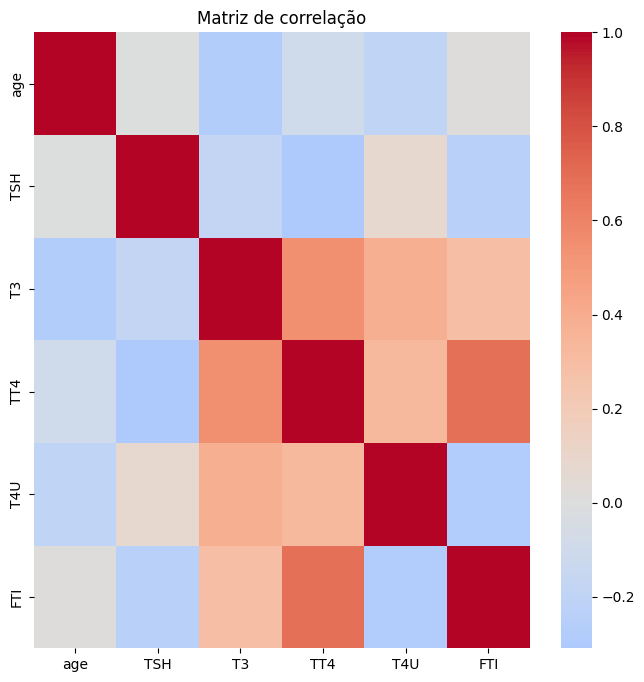

In [98]:
# Matriz de correlação entre variáveis numéricas

# Criar matriz de correlação
corr = df.corr(numeric_only=True)

# Plotar
plt.figure(figsize=(8,8))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de correlação')
plt.show()

A matriz de correlação mostra como as variáveis se relacionam entre si.
Observa-se que TT4 e FTI têm uma relação forte, indicando que costumam variar juntos e podem trazer informações parecidas. Também há uma relação moderada entre T3 e TT4, mostrando que esses exames tendem a seguir o mesmo comportamento.
Por outro lado, TSH e age apresentam pouca relação com as demais variáveis, indicando que seguem um padrão mais independente.
Isso mostra que algumas variáveis são semelhantes entre si, enquanto outras trazem informações diferentes, o que pode influenciar a construção do modelo.

In [99]:
# Modificar o target (objetivo) em 0 e 1
df['target'] = df['target'].astype('category').cat.codes

# Modificar todas as outras colunas de texto (Sim/Não, Sexo, etc) em números
df = pd.get_dummies(df, drop_first=True)

In [100]:
# Separação dos dados em treino e teste para avaliação do modelo

from sklearn.model_selection import train_test_split

X = df.drop('target', axis=1)
y = df['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)

Como os dados apresentavam desbalanceamento entre as classes, foi utilizado o parâmetro class_weight='balanced' na regressão logística para dar maior peso à classe minoritária e melhorar o aprendizado do modelo.

In [101]:
# Treinar o modelo

from sklearn.linear_model import LogisticRegression

# Modelo com ajuste para desbalanceamento
model = LogisticRegression(max_iter=1000, class_weight='balanced')

model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [102]:
# Fazer previsões

y_pred = model.predict(X_test)

In [103]:
# Avaliar o desempenho do modelo

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.56      0.93      0.70        30
           1       1.00      0.96      0.98       603

    accuracy                           0.96       633
   macro avg       0.78      0.95      0.84       633
weighted avg       0.98      0.96      0.97       633



O modelo apresentou 96% de acurácia, porém essa métrica não é a mais adequada devido ao desbalanceamento das classes.
Por se tratar de um problema na área da saúde, o principal risco está nos falsos negativos, ou seja, quando o modelo não identifica corretamente um caso positivo.
Nesse contexto, o recall da classe positiva foi de 96%, indicando que o modelo consegue identificar a maior parte dos casos de hypothyroid.
O F1-score da classe positiva foi de 0.98, mostrando um bom equilíbrio entre precisão e recall, ou seja, o modelo não apenas identifica bem os casos positivos, como também mantém baixa taxa de erro nessas previsões.
De forma geral, o modelo apresenta bom desempenho, sendo mais adequado avaliar principalmente o recall e o F1-score para uma análise mais confiável neste contexto.

In [104]:
y_prob = model.predict_proba(X_test)[:, 1]

# Ajustando threshold
y_pred_adjusted = (y_prob > 0.3).astype(int)

Para aumentar o recall da classe positiva, o threshold foi reduzido.

Isso faz com que o modelo identifique mais casos positivos e diminua o risco de falsos negativos, o que é essencial na área da saúde.

In [105]:
# Avaliar o modelo após ajustes

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.59      0.90      0.71        30
           1       0.99      0.97      0.98       603

    accuracy                           0.97       633
   macro avg       0.79      0.93      0.85       633
weighted avg       0.98      0.97      0.97       633



O threshold foi reduzido de 0.5 para 0.3 para aumentar o recall da classe positiva.
Após o ajuste, o modelo apresentou recall de 97% e F1-score de 0.98 para a classe positiva (hypothyroid), indicando alta capacidade de identificar os casos da doença.
A acurácia foi de 97%, porém essa métrica não é a mais adequada neste contexto.
Com esse ajuste, o modelo reduz o risco de não detectar casos positivos.

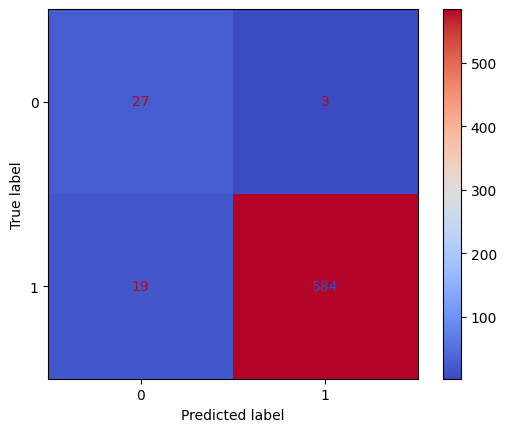

In [110]:
# Geração da matriz de confusão para avaliar os acertos e erros do modelo,
# destacando principalmente falsos positivos e falsos negativos

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_adjusted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='coolwarm')

A matriz de confusão mostra que o modelo identifica corretamente a maioria dos casos positivos, com 584 acertos. No entanto, ainda há 19 falsos negativos, ou seja, casos em que a doença não foi detectada, o que é crítico no contexto da saúde. Por outro lado, o número de falsos positivos é baixo, com apenas 3 ocorrências.
No eixo Y estão os valores reais e no eixo X estão as previsões do modelo, onde 0 representa negativo e 1 positivo.


In [117]:
# Avaliação de diferentes valores de threshold
# para reduzir falsos negativos e aumentar o recall da classe positiva

from sklearn.metrics import recall_score

# Probabilidades da classe positiva
y_prob = model.predict_proba(X_test)[:, 1]

# Testando diferentes thresholds
for t in [0.5, 0.4, 0.3, 0.2, 0.1]:
    # Aplicação do threshold
    y_pred_t = (y_prob > t).astype(int)

    # Cálculo do recall
    recall = recall_score(y_test, y_pred_t)

    print(f"Threshold: {t} | Recall: {recall:.3f}")

Threshold: 0.5 | Recall: 0.964
Threshold: 0.4 | Recall: 0.965
Threshold: 0.3 | Recall: 0.968
Threshold: 0.2 | Recall: 0.973
Threshold: 0.1 | Recall: 0.982


Foram testados diferentes valores de threshold para aumentar o recall da classe positiva.
O valor de 0.2 foi escolhido por melhorar a detecção dos casos da doença (recall de 97.3%), reduzindo os falsos negativos sem aumentar muito os falsos positivos.

In [118]:
# Aplicação do threshold escolhido
# Esse valor deve ser definido com base no melhor equilíbrio observado

y_pred_adjusted = (y_prob > 0.2).astype(int)

In [119]:
# Avaliação do modelo após ajuste do threshold

print(classification_report(y_test, y_pred_adjusted))

              precision    recall  f1-score   support

           0       0.63      0.90      0.74        30
           1       0.99      0.97      0.98       603

    accuracy                           0.97       633
   macro avg       0.81      0.94      0.86       633
weighted avg       0.98      0.97      0.97       633



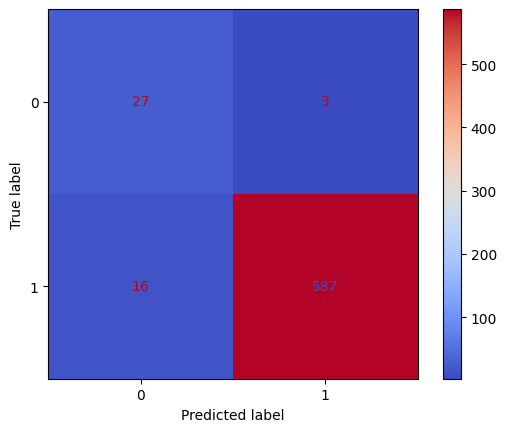

In [120]:
# Geração da matriz de confusão após ajuste do threshold para avaliar os
# acertos e erros do modelo, destacando principalmente falsos positivos e falsos
# negativos

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_adjusted)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='coolwarm')

Após o ajuste do threshold, os falsos negativos reduziram de 19 para 16, aumentando a detecção de casos positivos (de 584 para 587).
Por outro lado, os falsos positivos permaneceram baixos (3 casos), sem aumento significativo.
Essa mudança mostra que o modelo passou a identificar mais casos da doença, reduzindo o risco de não detecção, sem comprometer muito os erros.
No eixo Y estão os valores reais e no eixo X estão as previsões do modelo, onde 0 representa negativo e 1 positivo.

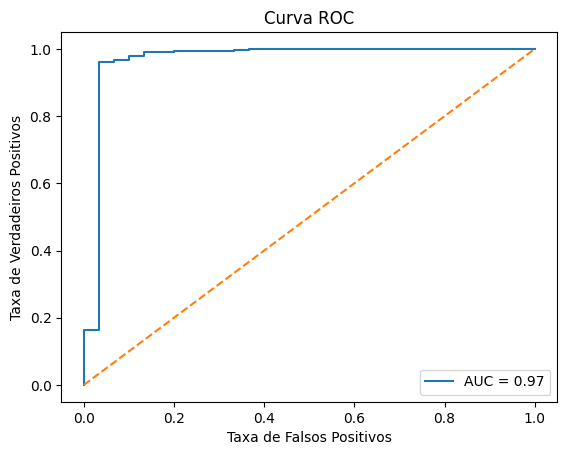

In [123]:
# Cálculo da curva ROC e da métrica AUC
# Avaliar a capacidade do modelo em separar as classes independentemente do
# threshold

from sklearn.metrics import roc_curve, auc

# Probabilidade da classe positiva
y_prob = model.predict_proba(X_test)[:, 1]

# Cálculo da curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Cálculo da AUC
roc_auc = auc(fpr, tpr)

# Plot da curva
plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], linestyle='--')  # linha de referência
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC')
plt.legend()
plt.show()

A curva ROC mostra que o modelo tem excelente capacidade de diferenciar as classes. O valor de AUC = 0.97 indica que o modelo consegue separar muito bem casos positivos e negativos.
A curva está próxima do canto superior esquerdo, o que significa alta taxa de acertos para casos positivos com baixa taxa de falsos positivos.

## Seguindo o mesmo padrão, será treinado um modelo de Random Forest para comparação com os resultados obtidos anteriormente.

In [129]:
# Treinamento do modelo Random Forest
# Utilizando class_weight para lidar com o desbalanceamento

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    random_state=42,
    class_weight='balanced')

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

In [130]:
# Previsões no conjunto de teste
y_pred_rf = rf.predict(X_test)

# Probabilidades (para ROC e threshold)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

In [131]:
# Avaliação do modelo
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.96      0.90      0.93        30
           1       1.00      1.00      1.00       603

    accuracy                           0.99       633
   macro avg       0.98      0.95      0.96       633
weighted avg       0.99      0.99      0.99       633




O modelo apresentou ótimo desempenho, com recall de 100% e F1-score de 1.00 para a classe positiva, indicando que praticamente todos os casos de doença foram identificados.
Para a classe negativa, o desempenho também foi bom, com poucos erros. No geral, o modelo mostrou alta precisão e equilíbrio entre as métricas.

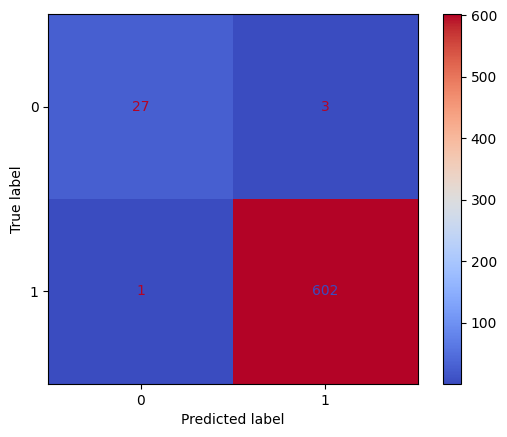

In [134]:
# Matriz de confusão
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot(cmap='coolwarm')

Na matriz de confusão, o eixo Y representa os valores reais e o eixo X representa as previsões do modelo, onde 0 indica negativo e 1 positivo.
O modelo identificou corretamente 602 casos positivos e 27 negativos.
Houve apenas 1 falso negativo, reduzindo significativamente o risco de não detectar a doença. Além disso, foram observados 3 falsos positivos, indicando baixo nível de erros desse tipo.

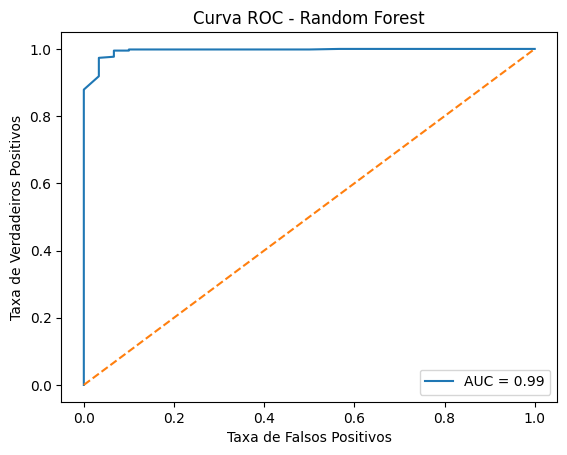

In [135]:
# Curva ROC e AUC

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
roc_auc_rf = auc(fpr_rf, tpr_rf)

plt.plot(fpr_rf, tpr_rf, label=f'AUC = {roc_auc_rf:.2f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('Taxa de Falsos Positivos')
plt.ylabel('Taxa de Verdadeiros Positivos')
plt.title('Curva ROC - Random Forest')
plt.legend()
plt.show()

A curva ROC apresentou AUC de 0.99, indicando excelente capacidade do modelo em diferenciar casos positivos e negativos.
O resultado mostra que o modelo possui alto poder de separação, reforçando sua eficácia para o problema.

Foi utilizado o modelo Random Forest como alternativa à Regressão Logística, por sua capacidade de capturar relações mais complexas entre as variáveis.
Devido ao desbalanceamento das classes, foi aplicado class_weight='balanced', garantindo maior atenção à classe minoritária.

## Conlusão

Ao longo do projeto, foi realizada a análise e modelagem de um dataset relacionado a diagnóstico de hipotireoidismo, com foco na identificação correta dos casos positivos.
Inicialmente, foi aplicada a Regressão Logística, que apresentou bom desempenho geral, com alta capacidade de identificação dos casos positivos. No entanto, ainda foram observados falsos negativos, o que representa um risco no contexto da saúde.
Com o ajuste do threshold, foi possível melhorar o recall da classe positiva, reduzindo a quantidade de casos não detectados.
Em seguida, foi aplicado o modelo Random Forest, que apresentou desempenho superior, com recall de 100% para a classe positiva, apenas 1 falso negativo e AUC de 0.99, demonstrando excelente capacidade de separação entre as classes.
Dessa forma, o modelo Random Forest se mostrou mais adequado para o problema, especialmente por reduzir significativamente o risco de não identificação da doença.
O modelo pode ser aprimorado com ajustes de parâmetros e validação cruzada, visando reduzir ainda mais os erros.